In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sc 
import statsmodels.api as sm
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.pipeline import Pipeline

In [3]:
df1 = pd.read_csv("nykaa_campaign_data_with_nulls.csv",encoding="cp1252")

In [4]:
df1.shape

(55555, 16)

In [5]:
df2 = pd.read_csv("purplle_campaign_data_with_nulls.csv",encoding="cp1252")

In [6]:
df2.shape

(55555, 16)

In [7]:
df3 = pd.read_csv("tira_campaign_data_with_nulls.csv",encoding="cp1252")

In [8]:
df3.shape

(55555, 16)

In [9]:
df = pd.concat([df1, df2, df3], ignore_index=True)

In [10]:
df.shape

(166665, 16)

In [11]:
df.to_csv("nykaapurplletira.csv", index=False)

In [12]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,NaN,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.60,NaN,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.07,0.60,Hindi,13.15,NaN,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


In [13]:
df.tail()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
166660,NaN,NaN,Tier 2 City Customers,11.0,"Instagram, YouTube, Email",NaN,3799.0,NaN,1099.0,454986.0,213.21,0.94,Bengali,10.70,Youth,12-11-2024
166661,TI-CMP-56551,SEO,Working Women,20.0,"Google, Instagram",54886.0,1578.0,634.0,NaN,136514.0,436.24,-0.09,English,4.66,Working Women,25-08-2024
166662,TI-CMP-56552,Email,NaN,13.0,"Facebook, Instagram",97954.0,11480.0,4567.0,2144.0,445952.0,78.77,1.64,NaN,18.57,Premium Shoppers,15-04-2025
166663,NaN,Influencer,Premium Shoppers,22.0,"Google, Email",11669.0,NaN,122.0,44.0,26884.0,NaN,-0.76,English,5.35,Working Women,21-07-2024
166664,TI-CMP-56554,Paid Ads,Working Women,NaN,Instagram,50497.0,1604.0,542.0,363.0,281688.0,151.44,4.12,English,4.97,Premium Shoppers,02-05-2025


In [14]:
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,158342.000000,158441.000000,158441.000000,158575.000000,158665.000000,1.583610e+05,158504.000000,158367.00000,158584.000000
mean,17.488582,55068.759456,4684.973978,1872.167157,1028.498213,5.138267e+05,376.830560,2.69620,13.764843
std,7.501765,25961.688169,3177.355919,1430.272768,857.687806,4.875933e+05,536.701697,4.48544,6.328162
min,5.000000,10001.000000,202.000000,48.000000,17.000000,3.895000e+03,8.180000,-0.99000,2.560000
25%,11.000000,32599.000000,2110.000000,779.000000,401.000000,1.775800e+05,106.760000,0.05000,8.380000
50%,17.000000,55113.000000,3908.000000,1476.000000,775.000000,3.588720e+05,208.725000,1.24000,13.590000
75%,24.000000,77582.000000,6695.000000,2600.000000,1403.000000,6.856400e+05,428.560000,3.58000,18.790000
max,30.000000,100000.000000,14944.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,79.30000,30.990000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166665 entries, 0 to 166664
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       161248 non-null  object 
 1   Campaign_Type     158307 non-null  object 
 2   Target_Audience   158493 non-null  object 
 3   Duration          158342 non-null  float64
 4   Channel_Used      158383 non-null  object 
 5   Impressions       158441 non-null  float64
 6   Clicks            158441 non-null  float64
 7   Leads             158575 non-null  float64
 8   Conversions       158665 non-null  float64
 9   Revenue           158361 non-null  float64
 10  Acquisition_Cost  158504 non-null  float64
 11  ROI               158367 non-null  float64
 12  Language          158366 non-null  object 
 13  Engagement_Score  158584 non-null  float64
 14  Customer_Segment  158490 non-null  object 
 15  Date              158566 non-null  object 
dtypes: float64(9), objec

In [16]:
df.columns

Index(['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration',
       'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions',
       'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'Date'],
      dtype='object')

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.isnull().sum()

Campaign_ID         5417
Campaign_Type       8358
Target_Audience     8172
Duration            8323
Channel_Used        8282
Impressions         8224
Clicks              8224
Leads               8090
Conversions         8000
Revenue             8304
Acquisition_Cost    8161
ROI                 8298
Language            8299
Engagement_Score    8081
Customer_Segment    8175
Date                8099
dtype: int64

In [19]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

Campaign_ID         3.250233
Campaign_Type       5.014850
Target_Audience     4.903249
Duration            4.993850
Channel_Used        4.969250
Impressions         4.934449
Clicks              4.934449
Leads               4.854049
Conversions         4.800048
Revenue             4.982450
Acquisition_Cost    4.896649
ROI                 4.978850
Language            4.979450
Engagement_Score    4.848648
Customer_Segment    4.905049
Date                4.859449
dtype: float64


In [13]:
df["ROI"] = (df["Revenue"] - df["Acquisition_Cost"]) / df["Acquisition_Cost"]

In [14]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

In [15]:
num_cols

Index(['Duration', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue',
       'Acquisition_Cost', 'ROI', 'Engagement_Score'],
      dtype='object')

In [16]:
df['Acquisition_Cost'] = df['Acquisition_Cost'].fillna(df['Acquisition_Cost'].mean())
df['Revenue'] = df['Revenue'].fillna(0)

In [17]:
df.isnull().sum()

Campaign_ID          5417
Campaign_Type        8358
Target_Audience      8172
Duration             8323
Channel_Used         8282
Impressions          8224
Clicks               8224
Leads                8090
Conversions          8000
Revenue                 0
Acquisition_Cost        0
ROI                 16064
Language             8299
Engagement_Score     8081
Customer_Segment     8175
Date                 8099
dtype: int64

In [18]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [19]:
df.isnull().sum() 

Campaign_ID         5417
Campaign_Type       8358
Target_Audience     8172
Duration               0
Channel_Used        8282
Impressions            0
Clicks                 0
Leads                  0
Conversions            0
Revenue                0
Acquisition_Cost       0
ROI                    0
Language            8299
Engagement_Score       0
Customer_Segment    8175
Date                8099
dtype: int64

In [20]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [21]:
df.isnull().sum() 

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [22]:
num_df = df.select_dtypes(include=['int64', 'float64'])

In [23]:
df['Campaign_Type'].unique()

array(['Social Media', 'Paid Ads', 'Influencer', 'Email', 'SEO'],
      dtype=object)

In [24]:
df['Target_Audience'].unique()

array(['College Students', 'Tier 2 City Customers', 'Youth',
       'Working Women', 'Premium Shoppers'], dtype=object)

In [25]:
df['Channel_Used'].unique()

array(['WhatsApp, YouTube', 'YouTube', 'WhatsApp, Google, YouTube',
       'YouTube, Facebook, Instagram', 'Facebook, Instagram',
       'Email, Instagram', 'YouTube, Google, WhatsApp', 'Email',
       'Facebook, WhatsApp, Email', 'Facebook, YouTube',
       'Email, Instagram, Facebook', 'Instagram',
       'Facebook, Instagram, Email', 'WhatsApp',
       'Google, YouTube, Instagram', 'Google, YouTube',
       'Instagram, YouTube, Google', 'Google, Email, WhatsApp',
       'YouTube, Facebook', 'Google, Facebook',
       'Google, Instagram, WhatsApp', 'Instagram, Google, YouTube',
       'WhatsApp, Instagram, Email', 'Email, Facebook, WhatsApp',
       'Email, Facebook, YouTube', 'Google, Facebook, WhatsApp',
       'Facebook, YouTube, Email', 'Facebook, YouTube, Instagram',
       'Instagram, WhatsApp, Facebook', 'WhatsApp, YouTube, Instagram',
       'Google, Instagram', 'Facebook, WhatsApp, Google', 'Google',
       'WhatsApp, Facebook', 'Email, Facebook', 'Instagram, Google',
      

In [26]:
df['Channel_Used'] = df['Channel_Used'].apply(lambda x: x.split(', '))

In [27]:
mlb = MultiLabelBinarizer()

In [28]:
channel = pd.DataFrame(mlb.fit_transform(df["Channel_Used"]),
    columns=mlb.classes_,index=df.index)

In [29]:
df = pd.concat([df.drop('Channel_Used', axis=1), channel], axis=1)

In [30]:
df['Language'].unique()

array(['Hindi', 'English', 'Tamil', 'Bengali'], dtype=object)

In [31]:
df['Customer_Segment'].unique()

array(['College Students', 'Youth', 'Tier 2 City Customers',
       'Premium Shoppers', 'Working Women'], dtype=object)

In [33]:
cols_to_encode = ['Campaign_Type', 'Target_Audience', 'Language','Customer_Segment']

preprocessor = ColumnTransformer(
    transformers=[("cat",OneHotEncoder(handle_unknown="ignore"),cols_to_encode),
                    ("num","passthrough",["Duration", "Impressions", "Clicks", "Leads",
        "Conversions", "Acquisition_Cost", "ROI", "Engagement_Score",
        "Email", "Facebook", "Google", "Instagram", "WhatsApp", "YouTube"])])


In [35]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,...,Language,Engagement_Score,Customer_Segment,Date,Email,Facebook,Google,Instagram,WhatsApp,YouTube
0,NY-CMP-1000,Social Media,College Students,21.0,57804.0,6156.0,3616.0,2355.0,1867515.0,376.83056,...,Hindi,20.98,College Students,29-04-2025,0,0,0,0,1,1
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18.0,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83000,...,Hindi,7.24,College Students,06-04-2025,0,0,0,0,0,1
2,NY-CMP-1002,Influencer,Youth,23.0,15536.0,2182.0,952.0,755.0,197055.0,90.60000,...,English,25.03,College Students,14-01-2025,0,0,1,0,1,1
3,NY-CMP-1003,Email,Working Women,18.0,88114.0,8413.0,2231.0,947.0,376906.0,249.07000,...,Hindi,13.15,Youth,04-06-2025,0,1,0,1,0,1
4,NY-CMP-1004,Paid Ads,College Students,10.0,96871.0,3743.0,2060.0,1258.0,518296.0,228.60000,...,Hindi,7.29,Tier 2 City Customers,29-12-2024,0,1,0,1,0,0


In [42]:
df.to_csv("cleaned_df.csv", index=False)

In [36]:
df = df.drop("Campaign_ID", axis=1)

In [37]:
df = df.drop("Date", axis=1)

In [38]:
corr = num_df.corr()

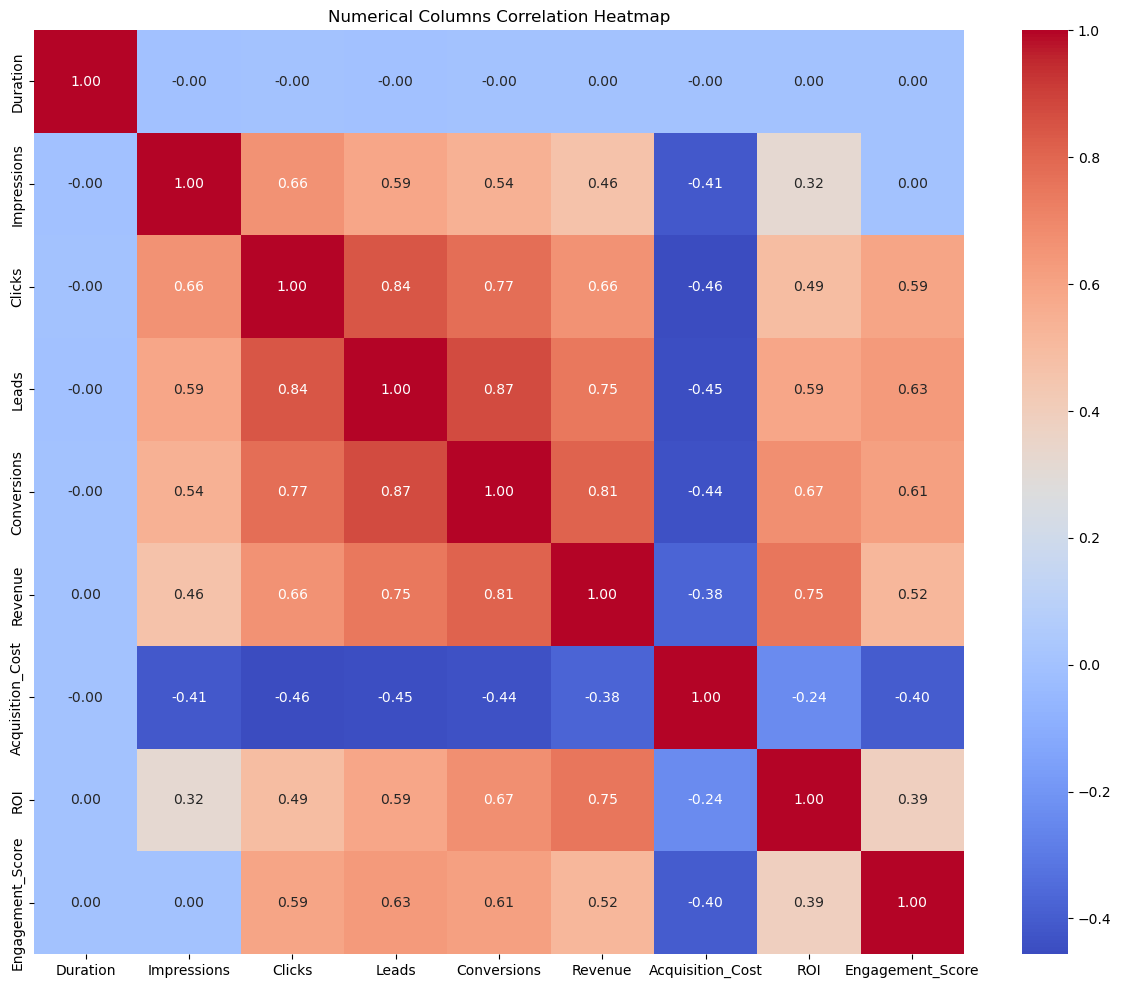

In [39]:
plt.figure(figsize=(15,12))
sns.heatmap(corr, annot=True,cmap="coolwarm", fmt=".2f")
plt.title("Numerical Columns Correlation Heatmap")
plt.show()

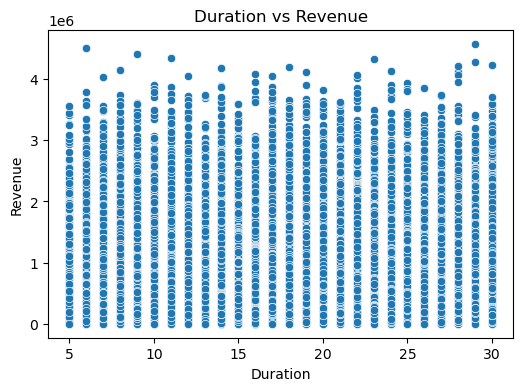

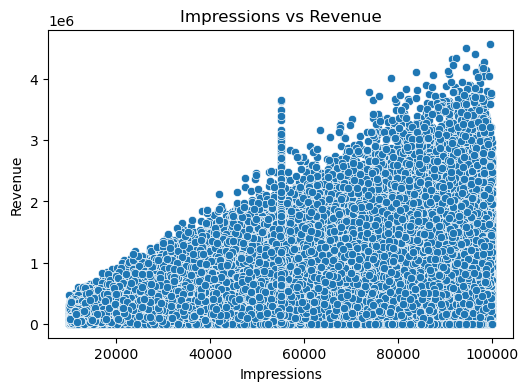

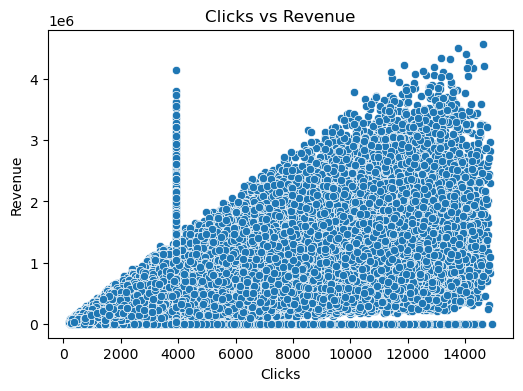

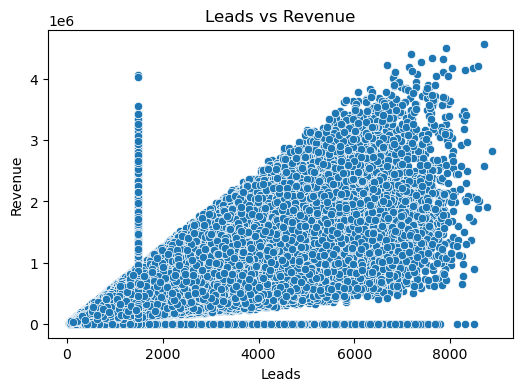

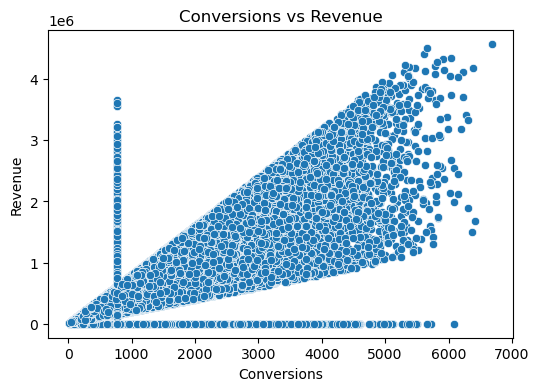

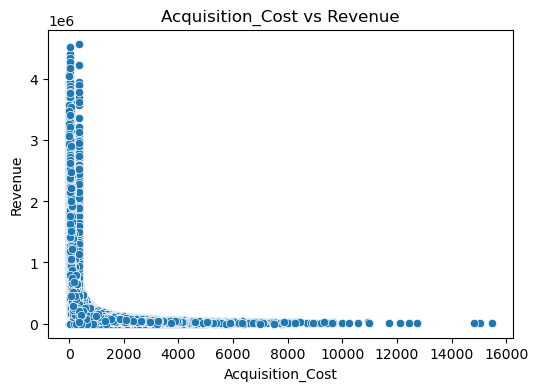

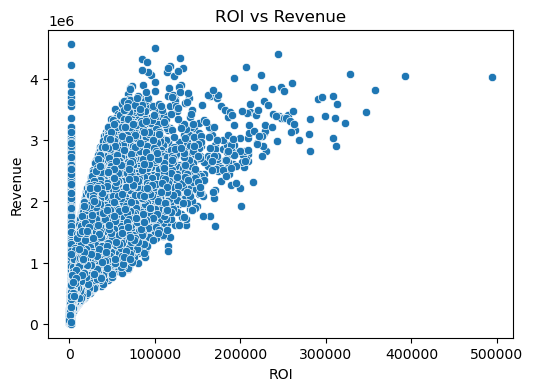

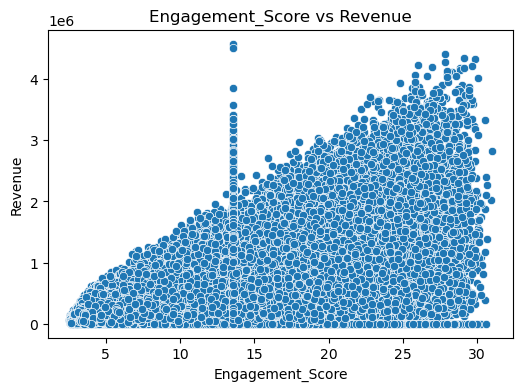

In [40]:
for col in num_df:
    
    if col != "Revenue":   
    
        plt.figure(figsize=(6,4))
        
        sns.scatterplot(
            data=df,
            x=col,
            y="Revenue"
        )
        
        plt.title(f"{col} vs Revenue")
        plt.xlabel(col)
        plt.ylabel("Revenue")
        plt.show()

<Axes: >

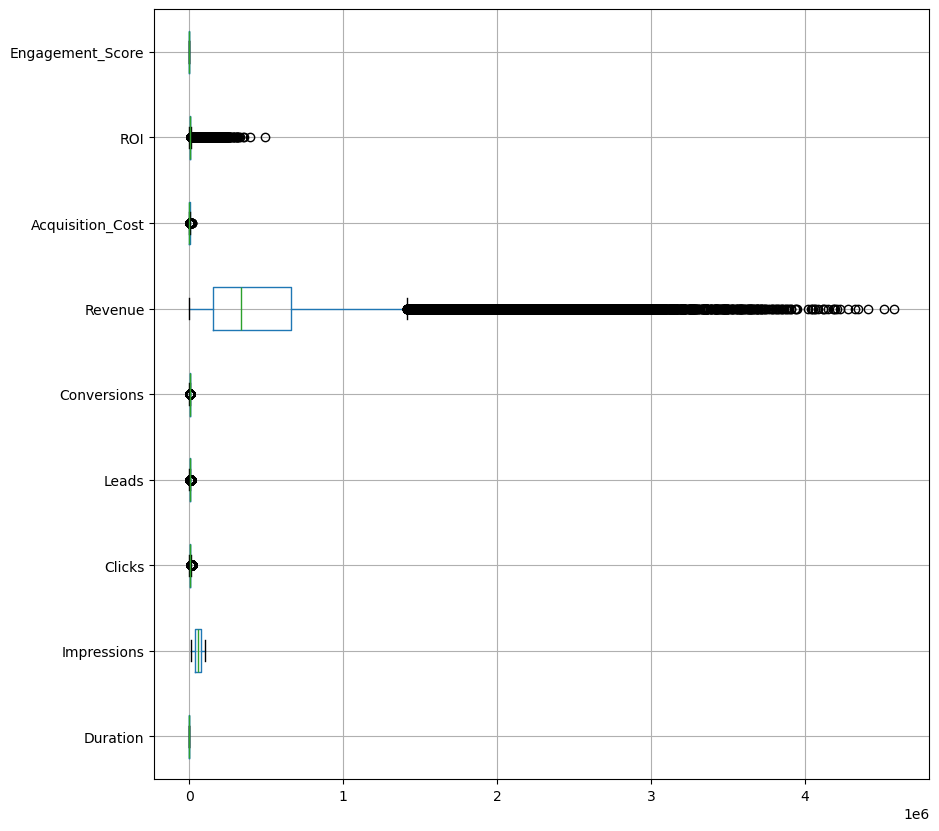

In [48]:
plt.figure(figsize=(10,10))
num_df.boxplot(vert=False)

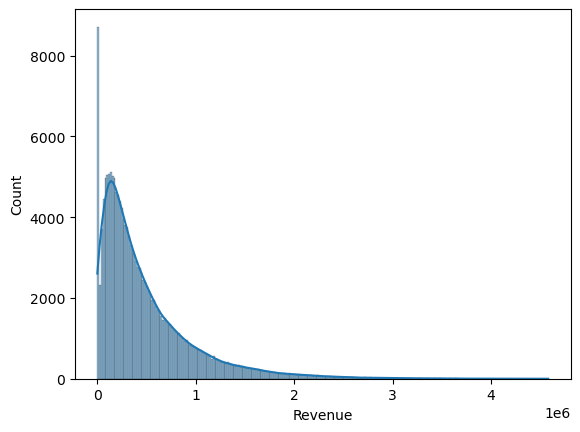

In [49]:
sns.histplot(df['Revenue'], kde=True)
plt.show()

In [50]:
df[['Acquisition_Cost','ROI','Conversions','Revenue','Clicks','Leads']].describe()

,Acquisition_Cost,ROI,Conversions,Revenue,Clicks,Leads
count,166665.000000,166665.000000,166665.000000,1.666650e+05,166665.000000,166665.000000
mean,376.830560,5984.246922,1016.330177,4.882256e+05,4646.634590,1852.937011
std,523.396497,13746.266571,838.602514,4.882630e+05,3102.538446,1397.723107
min,8.180000,-0.740989,17.000000,0.000000e+00,202.000000,48.000000
25%,111.100000,523.108096,417.000000,1.545830e+05,2185.000000,809.000000
50%,222.920000,1758.530792,775.000000,3.357800e+05,3908.000000,1476.000000
75%,410.920000,5308.009135,1357.000000,6.595050e+05,6510.000000,2525.000000
max,15473.160000,494114.403423,6686.000000,4.579910e+06,14944.000000,8876.000000


In [41]:
cols = ['Acquisition_Cost','ROI','Conversions','Clicks','Leads']

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5*IQR
    upper_limit = Q3 + 1.5*IQR

    df[col] = df[col].clip(lower_limit,upper_limit)

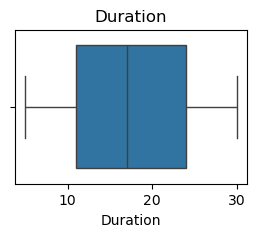

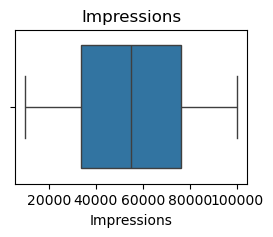

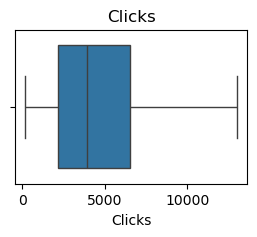

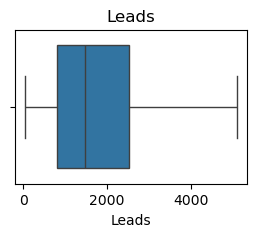

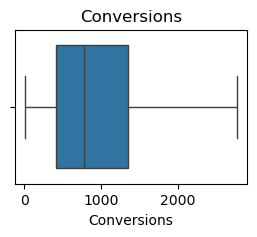

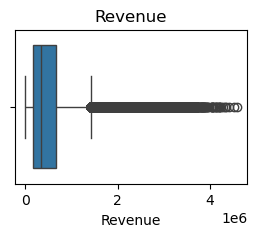

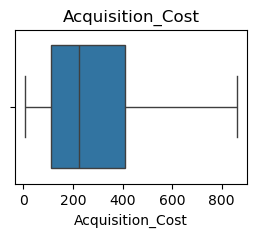

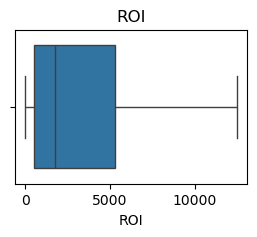

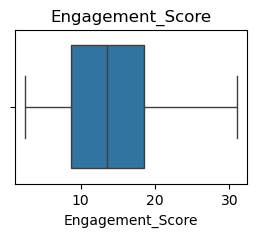

In [52]:
for col in num_cols:
    plt.figure(figsize=(3,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [42]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (r2_score,mean_absolute_error,mean_squared_error)

In [44]:
print(X.shape)
print(y.shape)

(166665, 18)
(166665,)


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30 , random_state=1)

In [57]:
X_train.shape

(116665, 18)

In [58]:
X_test.shape

(50000, 18)

In [59]:
y_train.shape

(116665,)

In [60]:
y_test.shape

(50000,)

In [63]:
X_train.columns

Index(['Campaign_Type', 'Target_Audience', 'Duration', 'Impressions', 'Clicks',
       'Leads', 'Conversions', 'Acquisition_Cost', 'ROI', 'Language',
       'Engagement_Score', 'Customer_Segment', 'Email', 'Facebook', 'Google',
       'Instagram', 'WhatsApp', 'YouTube'],
      dtype='object')

In [65]:
Lnr_regr = LinearRegression()
lr_pipeline = Pipeline([("preprocessor", preprocessor),("model", Lnr_regr)])
lr_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [66]:
ypred=lr_pipeline.predict(X_test)

In [67]:
ypred_train=lr_pipeline.predict(X_train)

In [68]:
print("R2_Test Score:", r2_score(y_test, ypred))
print("R2_Train Score:", r2_score(y_train, ypred_train))
print("MAE:", mean_absolute_error(y_test, ypred))
print("MSE:", mean_squared_error(y_test, ypred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ypred)))

R2_Test Score: 0.7273694738527846
R2_Train Score: 0.7255449800049729
MAE: 160739.31290842427
MSE: 64602249728.05043
RMSE: 254169.72622255867


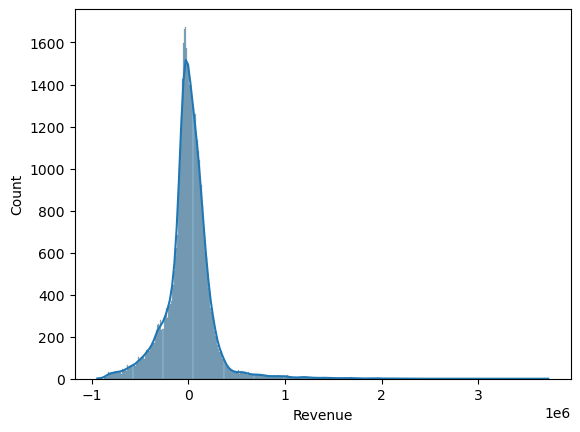

In [73]:
residuals = y_test - ypred

sns.histplot(residuals, kde=True)
plt.show()

In [77]:
importance = pd.DataFrame({
    "Feature": lr_pipeline.named_steps["preprocessor"].get_feature_names_out(),
    "Coefficient": lr_pipeline.named_steps["model"].coef_
})

importance.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
26,num__Engagement_Score,7498.296429
29,num__Google,4295.995587
0,cat__Campaign_Type_Email,2987.422635
16,cat__Customer_Segment_Tier 2 City Customers,2337.014537
2,cat__Campaign_Type_Paid Ads,1856.961419
8,cat__Target_Audience_Working Women,1766.602900
12,cat__Language_Hindi,1055.826016
11,cat__Language_English,867.265758
9,cat__Target_Audience_Youth,832.083175
30,num__Instagram,515.374023


In [46]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [47]:
from sklearn.ensemble import RandomForestRegressor

In [48]:
rf = RandomForestRegressor( n_estimators=200,max_depth=20,n_jobs=-1,random_state=42)
rf_pipeline = Pipeline([("preprocessor", preprocessor),("model", rf)])

In [49]:
rf_pipeline.fit(X_train, y_train_log)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [50]:
rf_pred = rf_pipeline.predict(X_test)

In [51]:
rf_trainpred = rf_pipeline.predict(X_train)

In [52]:
print("R2_test:", r2_score(y_test_log, rf_pred))
print("R2_train:", r2_score(y_train_log, rf_trainpred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, rf_pred)))

R2_test: 0.9525718068457367
R2_train: 0.9889243039202957
RMSE: 0.6342735325913943


In [84]:
from sklearn.tree import DecisionTreeRegressor

In [85]:
dt = DecisionTreeRegressor(max_depth=15,min_samples_split=10,min_samples_leaf=5,random_state=42)

In [86]:
dt_pipeline = Pipeline([("preprocessor", preprocessor),("model", dt)])

In [87]:
dt_pipeline .fit(X_train, y_train_log)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [88]:
dt_pred = dt_pipeline .predict(X_test)
dt_trainpred = dt_pipeline .predict(X_train)

In [89]:
print("R2_test:", r2_score(y_test_log, dt_pred))
print("R2_train:", r2_score(y_train_log, dt_trainpred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_log, dt_pred)))

R2_test: 0.9454436622657119
R2_train: 0.9637428906409226
RMSE: 0.6802693499103148


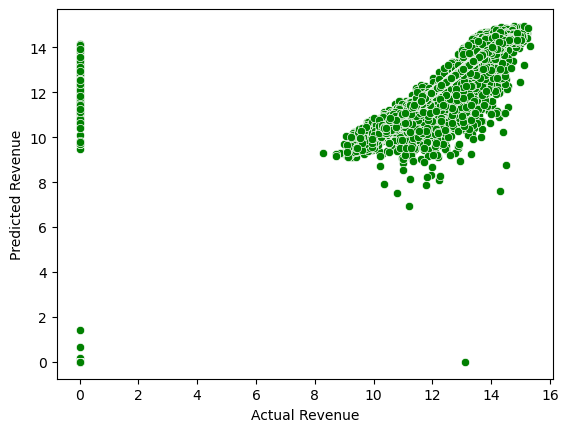

In [90]:
sns.scatterplot(x=y_test_log,y=rf_pred,color="green")

plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.show()

In [92]:
from sklearn.linear_model import Ridge, Lasso

In [93]:
ridge_model = Ridge(alpha=1.0)
ridge_pipeline = Pipeline([("preprocessor", preprocessor),("model", ridge_model)])
ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_test)
ridge_train= ridge_pipeline.predict(X_train)

In [94]:
print("Ridge R2 Score:", r2_score(y_test, ridge_pred))
print("Ridge R2 Score_train:", r2_score(y_train, ridge_train))
print("Ridge MAE:", mean_absolute_error(y_test, ridge_pred))
print("Ridge MSE:", mean_squared_error(y_test, ridge_pred))
print("Ridge RMSE:",np.sqrt(mean_squared_error(y_test, ridge_pred)))

Ridge R2 Score: 0.7273694789112699
Ridge R2 Score_train: 0.7255449800048802
Ridge MAE: 160739.30841329644
Ridge MSE: 64602248529.39696
Ridge RMSE: 254169.7238645802


In [96]:
lasso_model = Lasso(alpha=1.0)
lasso_pipeline = Pipeline([("preprocessor", preprocessor),("model", lasso_model)])
lasso_pipeline.fit(X_train, y_train)
lasso_pred = lasso_pipeline.predict(X_test)
lasso_train = lasso_pipeline.predict(X_train)

In [97]:
print("Lasso R2 Score:", r2_score(y_test, lasso_pred))
print("Lasso R2 Score_train:", r2_score(y_train, lasso_train))
print("Lasso MAE:", mean_absolute_error(y_test, lasso_pred))
print("Lasso MSE:", mean_squared_error(y_test, lasso_pred))
print("Lasso RMSE:",np.sqrt(mean_squared_error(y_test, lasso_pred)))

Lasso R2 Score: 0.7273698032715814
Lasso R2 Score_train: 0.7255449795775586
Lasso MAE: 160739.09710871478
Lasso MSE: 64602171669.31037
Lasso RMSE: 254169.57266618358


In [53]:
import joblib

models = {"random_forest": rf_pipeline}

joblib.dump(models, "Regr_models.pkl",compress=3)


['Regr_models.pkl']

In [54]:
df_clas=df.copy()

In [55]:
df_clas['Profit'] = df_clas['Revenue'] - df_clas['Acquisition_Cost']

df_clas['Profit_Loss'] = df_clas['Profit'].apply(lambda x: 1 if x > 0 else 0)


In [56]:
df_clas['Profit_Loss'].value_counts()

Profit_Loss
1    158361
0      8304
Name: count, dtype: int64

In [57]:
X_C = df_clas.drop('Profit_Loss', axis=1)  
y_C = df_clas['Profit_Loss']

In [58]:
X_trainc, X_testc, y_trainc, y_testc = train_test_split(X_C,y_C,test_size=0.3,random_state=42)

In [64]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

smote = SMOTE(random_state=42)
scaler = StandardScaler()


In [65]:
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler(with_mean=False)),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])


log_pipeline.fit(X_trainc, y_trainc)

y_pred_log = log_pipeline.predict(X_testc)


In [66]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_testc, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_testc, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_testc, y_pred_log))

Logistic Regression Accuracy: 0.44538

Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.65      0.11      2517
           1       0.96      0.43      0.60     47483

    accuracy                           0.45     50000
   macro avg       0.51      0.54      0.35     50000
weighted avg       0.91      0.45      0.57     50000


Confusion Matrix:
[[ 1641   876]
 [26855 20628]]


In [67]:
y_train_pred_log = log_pipeline.predict(X_trainc)
print("Train Accuracy:", accuracy_score(y_trainc, y_train_pred_log))


print("\nClassification Report:")
print(classification_report(y_trainc, y_train_pred_log))


print("\nConfusion Matrix:")
print(confusion_matrix(y_trainc, y_train_pred_log))

Train Accuracy: 0.45153216474521063

Classification Report:
              precision    recall  f1-score   support

           0       0.06      0.65      0.10      5787
           1       0.96      0.44      0.60    110878

    accuracy                           0.45    116665
   macro avg       0.51      0.54      0.35    116665
weighted avg       0.92      0.45      0.58    116665


Confusion Matrix:
[[ 3746  2041]
 [61946 48932]]


In [68]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced")
rfc_pipeline = Pipeline([("preprocessor", preprocessor),("smote", SMOTE(random_state=42)),("model",rf_model)])
rfc_pipeline.fit(X_trainc, y_trainc)

y_pred_rf = rfc_pipeline.predict(X_testc)

print("Random Forest Accuracy:",
      accuracy_score(y_testc, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_testc, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_testc, y_pred_rf))

Random Forest Accuracy: 0.99616

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96      2517
           1       1.00      1.00      1.00     47483

    accuracy                           1.00     50000
   macro avg       1.00      0.96      0.98     50000
weighted avg       1.00      1.00      1.00     50000


Confusion Matrix:
[[ 2325   192]
 [    0 47483]]


In [69]:
y_train_pred_rf = rfc_pipeline.predict(X_trainc)
print("Train Accuracy:", accuracy_score(y_trainc, y_train_pred_rf))

print("\nClassification Report:")
print(classification_report(y_trainc, y_train_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_trainc, y_train_pred_rf))

Train Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5787
           1       1.00      1.00      1.00    110878

    accuracy                           1.00    116665
   macro avg       1.00      1.00      1.00    116665
weighted avg       1.00      1.00      1.00    116665


Confusion Matrix:
[[  5787      0]
 [     0 110878]]


In [70]:
Classification_models = {"random_forest": rfc_pipeline}

joblib.dump(rfc_pipeline, "Class_model.pkl",compress=3)

['Class_model.pkl']